## Ce notebook a pour but d'explorer les résultats de notre algo de filtrage Kalman sur le dataset Rivesalt


In [148]:
import os
import pandas as pd
from pathlib import Path
import csv

base = Path.cwd() ## pointe vers folder parent, ici maneuver_detection

csv_path = Path(os.path.join(base, '..', '..', 'data', 'parsed', 'manual_labels_LEO', 'kalman_hyperparams_on_LEO.csv'))

out_dir = Path(os.path.join(base, '..', '..', 'data', 'parsed', 'manual_labels_LEO', 'analysis'))

def arange_results(csv_path, out_dir):
    """Crée un csv par f1 croissant"""
    df = pd.read_csv(csv_path)
    df = df.copy()
    out_dir_csv = Path(os.path.join(out_dir, 'best_f1.csv'))
    out_dir_csv.parent.mkdir(parents=True, exist_ok=True)
    df = df.sort_values("f1").to_csv(out_dir_csv, index=False)

    return out_dir_csv

out_dir_csv = arange_results(csv_path, out_dir)



In [149]:

def ratios(): 
    with open(out_dir_csv) as f:
        reader=csv.DictReader(f) ## chaque ligne = dict
        header = next(reader)
        fail = []
        mid = []
        good = []

        perfect = []
        for row in reader:
            norad= int(row['norad'])
            f1 = float(row['f1'])
            if f1 < 0.5: 
                fail.append(row)
            elif 0.5 <= f1 < 0.7 : 
                mid.append(row)
            elif 0.7 <= f1 < 1.0: 
                good.append(row)
            else :
                perfect.append(row)
        total = len(fail) + len(mid) + len(good) + len(perfect)
        fail_ratio = len(fail)/total
        mid_ratio = len(mid) / total
        good_ratio = len(good)/total
        perfect_ratio = len(perfect) / total

    print(fail_ratio, mid_ratio, good_ratio, perfect_ratio)
    return fail_ratio, mid_ratio, good_ratio, perfect_ratio
        
## avec méthode K-means pour rapprocher les objets en fonction des valeurs de varQ,r et p0
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import hdbscan

def clusters_params_filter_LEO(csv_path):
    df = pd.read_csv(csv_path)

    X = StandardScaler().fit_transform(df[['var_Q', 'r', 'p0']]) ## on mets les params à la même échelle

    clusters = hdbscan.HDBSCAN(min_cluster_size=3).fit_predict(X)

    df['cluster'] = clusters
    df.to_csv('best_f1_clusters.csv', index=False)


import matplotlib.pyplot as plt

def viz_on_params(csv_path):
    df=pd.read_csv(csv_path)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    Xs = StandardScaler().fit_transform(df[['var_Q', 'r', 'p0']])

    ax.scatter(Xs[:,0], 
               Xs[:,1], 
               Xs[:,2], 
               c=df.cluster, 
               cmap='tab10',
               s=10,
               alpha=0.8)
    ax.set_xlabel("VarQ")
    ax.set_ylabel("r")
    ax.set_zlabel("p0")

    ax.view_init(elev=50, azim=20)
    plt.tight_layout()
    plt.show()


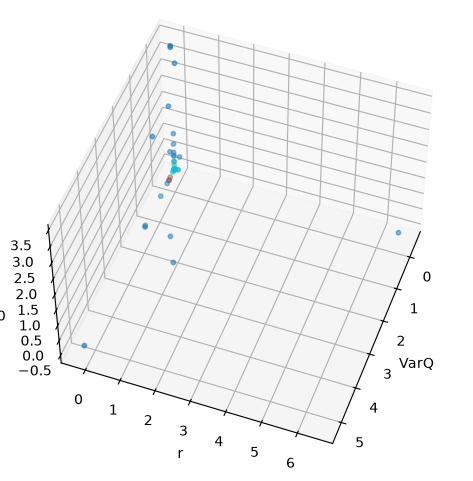

In [150]:

clusters_params_filter_LEO(csv_path)
base = Path.cwd() ## pointe vers folder parent, ici maneuver_detection

csv_path = Path(os.path.join(base, 'best_f1_clusters.csv'))

viz_on_params(csv_path)

In [ ]:

import numpy as np 
def stats_on_params(csv_path):
    df=pd.read_csv(csv_path)
    fig , axes = plt.subplots(1,3, figsize=(14,4))
    
    params = ['var_Q', 'r', 'p0']
    means = []
    var = []
    for ax, col in zip(axes, params):
        means.append(np.mean(df[col]))
        var.append(np.std(df[col]))
        ax.scatter(df.index, df[col], c=df['cluster'], cmap='tab10')
        ax.set_title(col)
        ax.set_xlabel('objet')
        ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()
    print(f"moyennes : varQ = {means[0]}, r = {means[1]}, p0= {means[2]}")
    print(f"variances : varQ = {var[0]}, r = {var[1]}, p0= {var[2]}" )
    return means, var
    

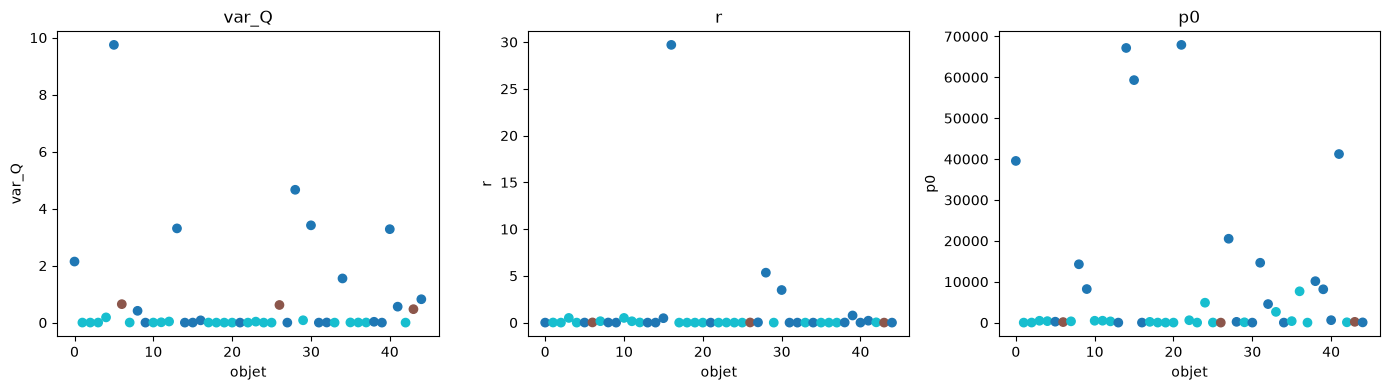

moyennes : varQ = 0.7139214377533307, r = 0.9204869173721874, p0= 8353.234868986756
variances : varQ = 1.7408692478975347, r = 4.436867231652898, p0= 17609.086222583792


([np.float64(0.7139214377533307),
  np.float64(0.9204869173721874),
  np.float64(8353.234868986756)],
 [np.float64(1.7408692478975347),
  np.float64(4.436867231652898),
  np.float64(17609.086222583792)])

In [152]:
stats_on_params(csv_path)

In [ ]:
from maneuver_detection.discrete_kalman_filter import detect_kalman
import polars as pl
## on utilise la catégorisation fail, mid, good définie au début, sets de norads passés à la fonction 

def run_filter_and_plot_with_optimal_params(norads, params, csv_path, path_tle_spacetrack):
    df = (
                pl.scan_parquet(path_tle_spacetrack)
                .filter(pl.col("norad") == norad)
                .select("epoch", "sma", "inclination")
                .sort("epoch")
                .collect()
            )
    
    with open(csv_path) as f: 
        reader=csv.DictReader(f) ## chaque ligne est un dict
        header=next(reader)
        for row in reader:
            norad = row['norad']
            if norad not in norads: 
                continue 
            var_Q = row['var_Q']
            r = row['r']
            p0 = row['p0']
            detect_kalman(df, ordre = row['order'], var_Q=var_Q, r=r, p0=p0)

def run_filter_and_plot_with_avg_params(norads, csv_path):

